<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Adabins_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Clone MiDaS repo
!git clone https://github.com/isl-org/MiDaS.git &> /dev/null
%cd MiDaS


/content/MiDaS


In [ ]:
!pip install -r requirements.txt &> /dev/null

In [ ]:
import torch
import cv2
import numpy as np
from torchvision.transforms import Compose

In [ ]:
model_type = "DPT_Large"  # good quality

midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)

# Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

transform = midas_transforms.dpt_transform

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:43<00:00, 31.3MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg to WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg


In [ ]:
img = cv2.imread("WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

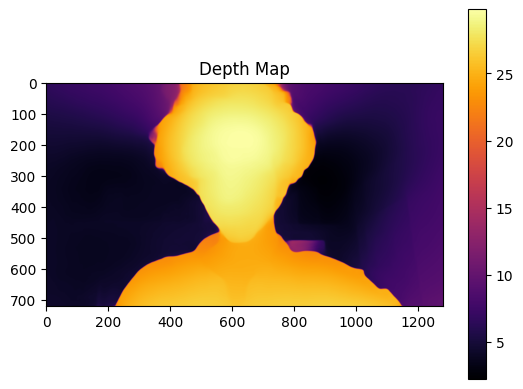

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(depth_map, cmap='inferno')
plt.colorbar()
plt.title("Depth Map")
plt.show()

In [ ]:
def create_bins(depth_map, num_bins):
    min_d = depth_map.min()
    max_d = depth_map.max()

    bins = np.linspace(min_d, max_d, num_bins)
    return bins

In [ ]:
def assign_bins(depth_map, bins):
    bin_indices = np.digitize(depth_map, bins)
    return bin_indices

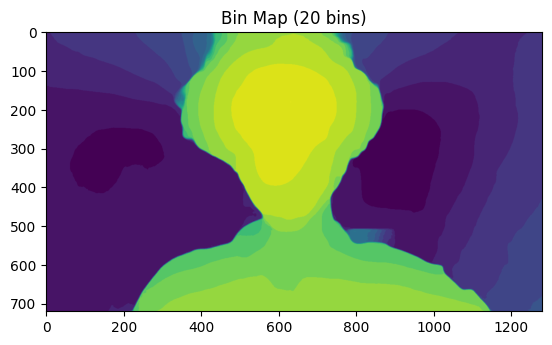

In [ ]:
num_bins = 20  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

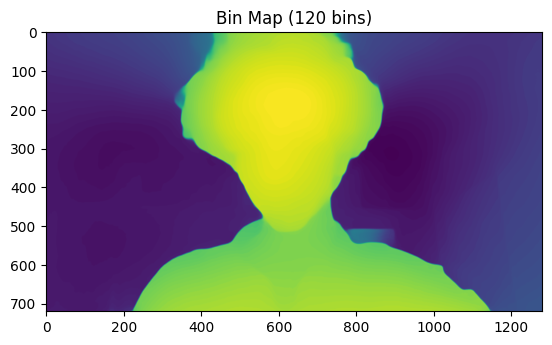

In [ ]:
num_bins = 120  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

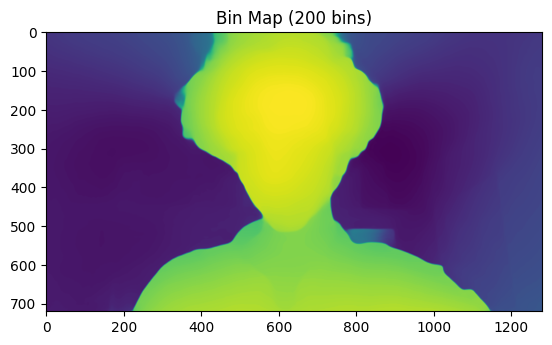

In [ ]:
num_bins = 200  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

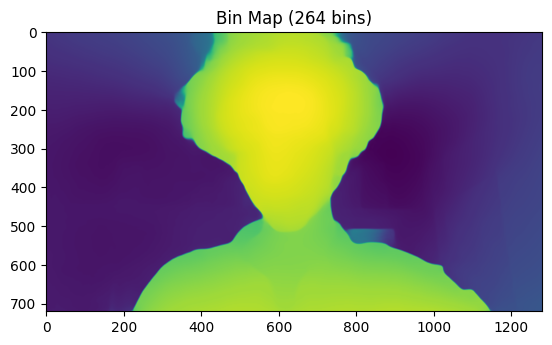

In [ ]:
num_bins = 264  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

### heuristic testing

In [ ]:
def compute_complexity(depth_map):
    return depth_map.std()

In [ ]:
def dynamic_bins(depth_map):
    complexity = compute_complexity(depth_map)

    if complexity < 0.1:
        return 32
    elif complexity < 0.2:
        return 64
    else:
        return 128

Chosen bins: 128


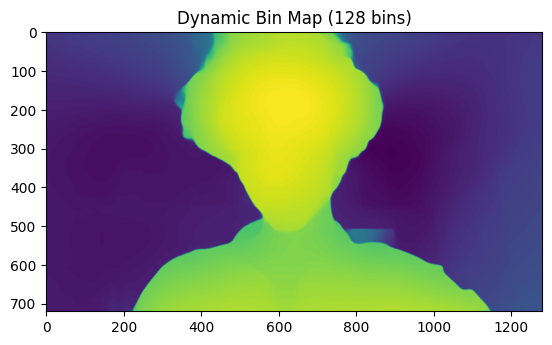

In [ ]:
num_bins = dynamic_bins(depth_map)

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

print("Chosen bins:", num_bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Dynamic Bin Map ({num_bins} bins)")
plt.show()

### Neural Network that predicts optimal number of bins from image

In [ ]:
import torch.nn as nn

class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = midas  # reuse MiDaS

    def forward(self, x):
        with torch.no_grad():
            features = self.model(x)
        return features

In [ ]:
class BinPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),  # compress spatial
            nn.Flatten(),
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # 3 classes: 32, 64, 128 bins
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class DynamicBinModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = FeatureExtractor()
        self.bin_predictor = BinPredictor()

    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.bin_predictor(features)
        return out

In [ ]:
bin_classes = [32, 64, 128]

In [ ]:
def get_label(depth_map):
    std = depth_map.std()

    if std < 0.1:
        return 0  # 32 bins
    elif std < 0.2:
        return 1  # 64 bins
    else:
        return 2  # 128 bins

In [ ]:
model = DynamicBinModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()

for epoch in range(5):
    optimizer.zero_grad()

    # Forward
    outputs = model(input_batch)

    # Get label
    label = torch.tensor([get_label(depth_map)]).to(device)

    loss = criterion(outputs, label)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 4.332095146179199
Epoch 1, Loss: 4.157260417938232
Epoch 2, Loss: 3.983149766921997
Epoch 3, Loss: 3.809865951538086
Epoch 4, Loss: 3.6375269889831543


In [ ]:
model.eval()

with torch.no_grad():
    pred = model(input_batch)
    bin_idx = torch.argmax(pred).item()

num_bins = bin_classes[bin_idx]

print("Predicted bins:", num_bins)

Predicted bins: 64


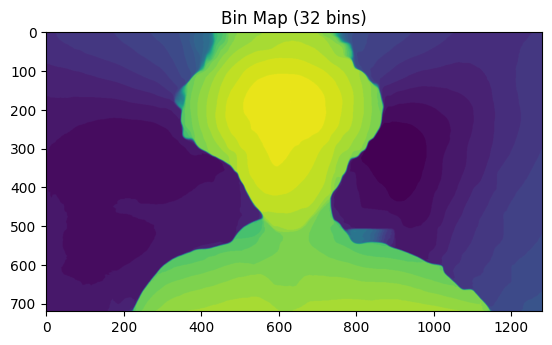

In [ ]:
num_bins = 32  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

## now building on real dataset


In [ ]:
import os

# Create folders
os.makedirs("dataset/rgb", exist_ok=True)
os.makedirs("dataset/depth", exist_ok=True)

print("Folders created!")

Folders created!


In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list -s nyu

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets download -d soumikrakshit/nyu-depth-v2

Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2
License(s): unknown
100% 4.10G/4.10G [02:25<00:00, 30.2MB/s]



In [ ]:
!unzip nyu-depth-v2.zip -d nyu_data

Streaming output truncated to the last 5000 lines.
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/32.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/32.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/33.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/33.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/34.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/34.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/35.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/35.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/36.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/36.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/37.jpg  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_out/37.png  
  inflating: nyu_data/nyu_data/data/nyu2_train/playroom_0004_

In [ ]:
!ls nyu_data

nyu_data


In [ ]:
!find nyu_data | head -50

nyu_data
nyu_data/nyu_data
nyu_data/nyu_data/data
nyu_data/nyu_data/data/nyu2_train.csv
nyu_data/nyu_data/data/nyu2_train
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/17.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/62.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/99.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/46.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/79.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/114.png
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/28.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/67.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/74.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/118.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/61.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/32.jpg
nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/70.jpg
n

In [ ]:
import os
import glob

In [ ]:
base_path = "nyu_data/nyu_data/data/nyu2_train"

rgb_files = []
depth_files = []

# Search scene folders
folders = glob.glob(base_path + "/*")

for folder in folders:
    jpgs = glob.glob(folder + "/*.jpg")

    for jpg in jpgs:
        name = os.path.splitext(os.path.basename(jpg))[0]
        png = os.path.join(folder, name + ".png")

        if os.path.exists(png):
            rgb_files.append(jpg)
            depth_files.append(png)

print("Pairs found:", len(rgb_files))
print(rgb_files[:5])
print(depth_files[:5])

Pairs found: 50688
['nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/28.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/67.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/74.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/118.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/61.jpg']
['nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/28.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/67.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/74.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/118.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/61.png']


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

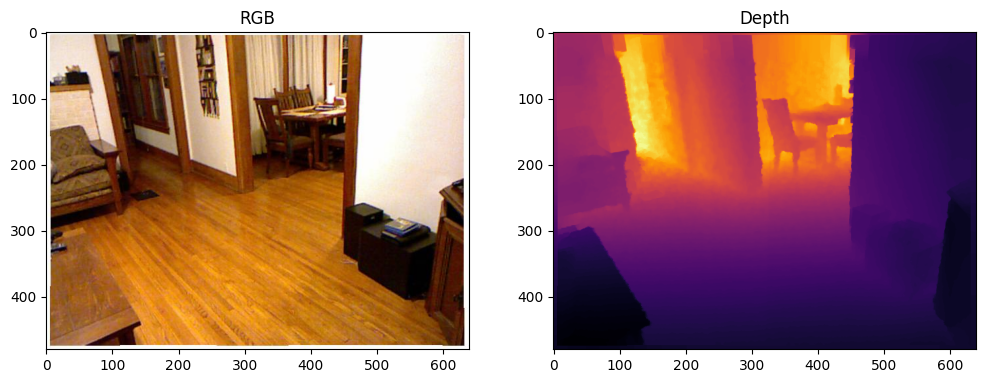

In [ ]:
img = Image.open(rgb_files[0])
depth = Image.open(depth_files[0])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(depth, cmap='inferno')
plt.title("Depth")

plt.show()

### buidling pair loader


In [ ]:
import os
import glob

In [ ]:
base_path = "nyu_data/nyu_data/data/nyu2_train"

rgb_files = []
depth_files = []

folders = glob.glob(base_path + "/*")

for folder in folders:
    jpgs = glob.glob(folder + "/*.jpg")

    for jpg in jpgs:
        name = os.path.splitext(os.path.basename(jpg))[0]
        png = os.path.join(folder, name + ".png")

        if os.path.exists(png):
            rgb_files.append(jpg)
            depth_files.append(png)

print("Pairs found:", len(rgb_files))
print("Sample RGB:", rgb_files[:3])
print("Sample Depth:", depth_files[:3])

Pairs found: 50688
Sample RGB: ['nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/28.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/67.jpg', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/74.jpg']
Sample Depth: ['nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/28.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/67.png', 'nyu_data/nyu_data/data/nyu2_train/living_room_0086a_out/74.png']


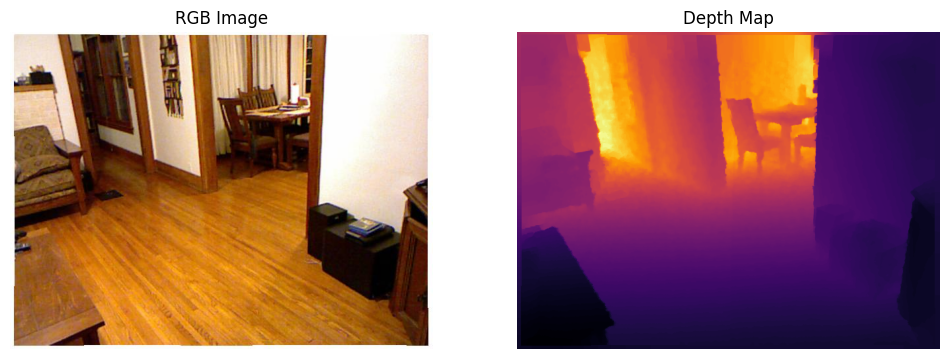

In [ ]:
img = Image.open(rgb_files[0]).convert("RGB")
depth = Image.open(depth_files[0])

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(depth, cmap="inferno")
plt.title("Depth Map")
plt.axis("off")

plt.show()

### creating labels for each image -> [32, 64, 128, 256]


In [ ]:
import numpy as np
from PIL import Image

In [ ]:
bin_choices = [32, 64, 128, 256]

def quantize_depth(depth, bins):
    depth = depth.astype(np.float32)

    min_d = depth.min()
    max_d = depth.max()

    edges = np.linspace(min_d, max_d, bins)

    indices = np.digitize(depth, edges)
    indices = np.clip(indices - 1, 0, bins - 1)

    recon = edges[indices]
    return recon

def mse(a, b):
    return np.mean((a - b) ** 2)

def best_bin_label(depth, lam=0.05):
    scores = []
    errors = []

    for b in bin_choices:
        recon = quantize_depth(depth, b)
        err = mse(depth, recon)

        cost = b / 256.0
        score = err + lam * cost

        scores.append(score)
        errors.append(err)

    best_idx = np.argmin(scores)
    return best_idx, errors, scores

testing on one sample

In [ ]:
depth = np.array(Image.open(depth_files[0]))

label, errors, scores = best_bin_label(depth)

print("Errors:", errors)
print("Scores:", scores)
print("Chosen bins:", bin_choices[label])

Errors: [np.float32(7.29881), np.float32(1.4793789), np.float32(0.42941055), np.float32(0.11040456)]
Scores: [np.float32(7.30506), np.float32(1.491879), np.float32(0.45441055), np.float32(0.16040456)]
Chosen bins: 256


the image is still giving 256 bins, so trying to change the lambda in order t ofindout whether our work is worth reasearch!

In [ ]:
for lam in [0.1, 0.2, 0.3, 0.5, 1.0]:
    label, errors, scores = best_bin_label(depth, lam=lam)
    print("lambda =", lam, " -> chosen bins =", bin_choices[label])

lambda = 0.1  -> chosen bins = 256
lambda = 0.2  -> chosen bins = 256
lambda = 0.3  -> chosen bins = 256
lambda = 0.5  -> chosen bins = 256
lambda = 1.0  -> chosen bins = 128


In [ ]:
import random
from collections import Counter

In [ ]:
lam = 0.2
num_samples = 100   # test on 100 random images

counts = Counter()

sample_ids = random.sample(range(len(depth_files)), num_samples)

for idx in sample_ids:
    depth = np.array(Image.open(depth_files[idx]))
    label, _, _ = best_bin_label(depth, lam=lam)
    counts[bin_choices[label]] += 1

print("Label Distribution:")
for b in bin_choices:
    print(f"{b} bins :", counts[b])

Label Distribution:
32 bins : 2
64 bins : 4
128 bins : 30
256 bins : 64


In [ ]:
for lam in [0.3, 0.4, 0.5, 0.7]:
    counts = Counter()

    sample_ids = random.sample(range(len(depth_files)), 100)

    for idx in sample_ids:
        depth = np.array(Image.open(depth_files[idx]))
        label, _, _ = best_bin_label(depth, lam=lam)
        counts[bin_choices[label]] += 1

    print(f"\nLambda = {lam}")
    for b in bin_choices:
        print(f"{b} bins : {counts[b]}")


Lambda = 0.3
32 bins : 0
64 bins : 5
128 bins : 46
256 bins : 49

Lambda = 0.4
32 bins : 1
64 bins : 7
128 bins : 54
256 bins : 38

Lambda = 0.5
32 bins : 0
64 bins : 13
128 bins : 48
256 bins : 39

Lambda = 0.7
32 bins : 3
64 bins : 14
128 bins : 47
256 bins : 36


generating dataset labels for 1000 images

In [ ]:
subset_size = 1000

train_rgb = rgb_files[:subset_size]
train_depth = depth_files[:subset_size]

labels = []

for i in range(subset_size):
    depth = np.array(Image.open(train_depth[i]))
    label, _, _ = best_bin_label(depth, lam=0.5)
    labels.append(label)

print("Done!")
print("Sample labels:", labels[:20])

Done!
Sample labels: [np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(3)]


In [ ]:
import random

In [ ]:
subset_size = 1000

# random indices
indices = random.sample(range(len(rgb_files)), subset_size)

# build randomized subset
train_rgb = [rgb_files[i] for i in indices]
train_depth = [depth_files[i] for i in indices]

# regenerate labels from scratch
labels = []

for path in train_depth:
    depth = np.array(Image.open(path))
    label, _, _ = best_bin_label(depth, lam=0.5)
    labels.append(int(label))

print("Done generating labels")

counts = Counter(labels)
print("Label counts:", counts)
print("First 20 labels:", labels[:20])

Done generating labels
Label counts: Counter({2: 488, 3: 379, 1: 126, 0: 7})
First 20 labels: [3, 3, 2, 2, 1, 2, 3, 2, 3, 3, 3, 2, 1, 3, 3, 2, 2, 1, 2, 2]


32 class (0 class) labels are very few so we will remove them from the classes and now only 3 classes

In [ ]:
new_rgb = []
new_labels = []

for img_path, label in zip(train_rgb, labels):
    if label == 0:
        continue

    new_rgb.append(img_path)

    if label == 1:
        new_labels.append(0)   # 64
    elif label == 2:
        new_labels.append(1)   # 128
    elif label == 3:
        new_labels.append(2)   # 256

print("Filtered samples:", len(new_rgb))

from collections import Counter
print("New counts:", Counter(new_labels))

Filtered samples: 993
New counts: Counter({1: 488, 2: 379, 0: 126})


## will train an adaptive bin predictor now

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [ ]:
class BinDataset(Dataset):
    def __init__(self, img_paths, labels):
        self.img_paths = img_paths
        self.labels = labels

        self.tf = T.Compose([
            T.Resize((224,224)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.tf(img)
        label = self.labels[idx]
        return img, label

In [ ]:
dataset = BinDataset(new_rgb, new_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
import torch.nn as nn

In [ ]:
class BinNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,3)
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BinNet().to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        loss = loss_fn(out, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 1: Loss = 63.4030
Epoch 2: Loss = 62.2325
Epoch 3: Loss = 61.6878
Epoch 4: Loss = 61.8240
Epoch 5: Loss = 62.5090
Epoch 6: Loss = 61.4762
Epoch 7: Loss = 61.8569
Epoch 8: Loss = 61.6018
Epoch 9: Loss = 61.1656
Epoch 10: Loss = 60.9260


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = 100 * correct / total
print("Training Accuracy:", acc)

Training Accuracy: 49.14400805639476


okay, so the accuracy is 49.144 which is nice based on the Tiny CNN we are using, so now will upgradet he model to ResNet18 and then try
